# Sprint 2 — Diversity-Aware Retrieval

**CONTEXT MATTERS — Evaluating Diversity-Aware Retrieval for RAG**

This notebook presents the frozen Sprint 2 diversification experiment across **PubMedQA, HotpotQA, and ASQA**.

It does **not** rerun retrieval, diversification, generation, embeddings, evaluation, or scientific plots. All numerical values are loaded from already-frozen project artifacts.


## 1. Scientific question

Sprint 2 asks:

> **What happens to the retrieved evidence when relevance-only Top-5 selection is replaced by diversity-aware selection from the same Top-20 candidate pool?**

Final conditions:

1. `none`
2. `mmr_0`
3. `mmr_0.25`
4. `mmr_0.5`
5. `mmr_0.75`
6. `kmeans_k2`
7. `agglo_k3`
8. `dpp_map`

`none` is the relevance-ranked baseline and is **not** equivalent to `mmr_0`.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

HERE = Path.cwd()
DATA = HERE / "data"
FIGURES = HERE / "figures"

metrics_path = DATA / "SPRINT2_CONDITION_METRICS_LONG.csv"
manifest_path = DATA / "SPRINT2_NOTEBOOK_INPUT_MANIFEST_CANONICAL.csv"
f14_path = FIGURES / "F14_phase44_retrieval_diversity_by_condition.png"

for path in [metrics_path, manifest_path, f14_path]:
    if not path.is_file():
        raise FileNotFoundError(path)

metrics = pd.read_csv(metrics_path)
manifest = pd.read_csv(manifest_path)

print("Normalized metric rows:", len(metrics))
print("Canonical input artifacts:", len(manifest))
print("Datasets:", sorted(metrics["dataset"].unique()))
print(
    "Dataset × retriever pairs:",
    metrics[["dataset", "retriever"]].drop_duplicates().shape[0]
)


Normalized metric rows: 376
Canonical input artifacts: 18
Datasets: ['asqa', 'hotpotqa', 'pubmedqa']
Dataset × retriever pairs: 11


## 2. Frozen experimental scope

| Dataset | Population | Retrievers |
|---|---:|---|
| PubMedQA | 1,000 questions | BM25, DPR, Contriever, ColBERTv2 |
| HotpotQA | 7,405 official test queries | BM25, DPR, Contriever, ColBERTv2 |
| ASQA | 948 protected-final dev questions | BM25, DPR, Contriever |

Common design:

- candidate pool = **20**
- final selected context = **Top-5**
- diversification conditions = **8**
- no new tuning or generation sweep


In [2]:
condition_order = [
    "none",
    "mmr_0",
    "mmr_0.25",
    "mmr_0.5",
    "mmr_0.75",
    "kmeans_k2",
    "agglo_k3",
    "dpp_map",
]

assert set(metrics["condition"]) == set(condition_order)

pair_counts = (
    metrics[["dataset", "retriever"]]
    .drop_duplicates()
    .groupby("dataset")
    .size()
)

display(pair_counts.rename("retrievers").to_frame())


,retrievers
dataset,
asqa,3
hotpotqa,4
pubmedqa,4


## 3. Metric interpretation

For PubMedQA and HotpotQA, the frozen Sprint 2 retrieval summaries include relevance-oriented quantities such as `mean_recall_at_5` and `mean_mrr_at_5`.

For protected-final ASQA, the available final8 evidence used here is the frozen retrieval-diversity diagnostic.

For five selected passages:

\[
D = \frac{1}{\binom{5}{2}}
\sum_{i<j}
\left(1-\cos(e_i,e_j)\right)
\]

Higher values mean the selected passages are farther apart in the frozen embedding space.

This is a **manipulation diagnostic**, not an independent answer-quality metric.


In [3]:
def metric_table(dataset, metric_name):
    x = metrics[
        (metrics["dataset"] == dataset)
        & (metrics["metric_path"] == metric_name)
    ].copy()

    if x.empty:
        return None

    x["value"] = pd.to_numeric(x["value"], errors="coerce")

    table = x.pivot(
        index="retriever",
        columns="condition",
        values="value",
    )

    return table.reindex(columns=condition_order)


## 4. PubMedQA — retrieval relevance


In [4]:
pqa_recall = metric_table("pubmedqa", "mean_recall_at_5")
if pqa_recall is None:
    print("PubMedQA Recall@5 unavailable.")
else:
    display(pqa_recall.round(6))


condition,none,mmr_0,mmr_0.25,mmr_0.5,mmr_0.75,kmeans_k2,agglo_k3,dpp_map
retriever,,,,,,,,
bm25,0.599211,0.285313,0.333642,0.489363,0.568955,0.574450,0.491823,0.430894
colbertv2,0.738210,0.312213,0.409192,0.653191,0.713052,0.711837,0.574646,0.567894
contriever,0.740371,0.318104,0.485150,0.697628,0.730879,0.717364,0.584026,0.620281
dpr,0.325259,0.175696,0.221577,0.285437,0.311933,0.313249,0.298816,0.262344


In [5]:
pqa_mrr = metric_table("pubmedqa", "mean_mrr_at_5")
if pqa_mrr is None:
    print("PubMedQA MRR@5 unavailable.")
else:
    display(pqa_mrr.round(6))


condition,none,mmr_0,mmr_0.25,mmr_0.5,mmr_0.75,kmeans_k2,agglo_k3,dpp_map
retriever,,,,,,,,
bm25,0.911517,0.890567,0.906850,0.912467,0.912017,0.908550,0.906567,0.911967
colbertv2,0.976233,0.968600,0.975950,0.977083,0.976283,0.974667,0.974567,0.977117
contriever,0.972117,0.964683,0.971733,0.972733,0.972367,0.970550,0.970383,0.972567
dpr,0.578683,0.520800,0.565367,0.575817,0.578133,0.567583,0.568767,0.573883


### PubMedQA interpretation

The frozen results show a relevance–diversity trade-off rather than a universal improvement.

Diversity-heavy operating points can substantially reduce relevance-oriented retrieval metrics, while more relevance-preserving operating points often recover part of that loss.

The defensible conclusion is configuration-dependent: **dataset × retriever × diversification setting matters**.


## 5. HotpotQA — retrieval relevance

HotpotQA uses corpus-level retrieval over the full BEIR corpus rather than the small distractor setting.


In [6]:
hotpot_recall = metric_table("hotpotqa", "mean_recall_at_5")
if hotpot_recall is None:
    print("HotpotQA Recall@5 unavailable.")
else:
    display(hotpot_recall.round(6))


condition,none,mmr_0,mmr_0.25,mmr_0.5,mmr_0.75,kmeans_k2,agglo_k3,dpp_map
retriever,,,,,,,,
bm25,0.437272,0.327819,0.391425,0.427009,0.435854,0.427616,0.423363,0.417556
colbertv2,0.635179,0.455841,0.569953,0.624308,0.633626,0.625861,0.622485,0.609251
contriever,0.459487,0.288859,0.370966,0.430385,0.450979,0.439905,0.437542,0.416813
dpr,0.281026,0.196826,0.245442,0.270695,0.278325,0.273531,0.270898,0.262255


In [7]:
hotpot_mrr = metric_table("hotpotqa", "mean_mrr_at_5")
if hotpot_mrr is None:
    print("HotpotQA MRR@5 unavailable in this frozen summary layer.")
else:
    display(hotpot_mrr.round(6))


HotpotQA MRR@5 unavailable in this frozen summary layer.


### HotpotQA interpretation

HotpotQA shows the same broad tension: aggressively favoring novelty can remove supporting evidence retained by relevance-ranked Top-5 retrieval.

The size of the trade-off varies across retrievers, which is why the final experiment preserves multiple diversification operating points.


## 6. ASQA — protected-final retrieval diversity

ASQA uses the full protected-final dev set with **BM25, DPR, and Contriever**.

ColBERTv2 was not completed for the full ASQA corpus and is therefore not reported as a final ASQA retriever.


In [8]:
asqa_div = metric_table("asqa", "mean_retrieval_diversity")

if asqa_div is None:
    raise RuntimeError(
        "Protected-final ASQA retrieval-diversity values are missing."
    )

display(asqa_div.round(6))


condition,none,mmr_0,mmr_0.25,mmr_0.5,mmr_0.75,kmeans_k2,agglo_k3,dpp_map
retriever,,,,,,,,
bm25,0.574373,0.716571,0.676818,0.620776,0.589559,0.603606,0.614459,0.645566
contriever,0.569581,0.692151,0.652128,0.603133,0.580500,0.597864,0.607933,0.622299
dpr,0.524387,0.679629,0.640158,0.572010,0.539632,0.563651,0.582222,0.606138


### ASQA interpretation

The final8 ASQA results confirm that diversification changes the selected evidence composition.

Diversity-heavy MMR operating points increase the frozen Top-5 embedding-distance diagnostic relative to the relevance-only baseline.

This demonstrates that the intervention manipulates retrieval diversity; it does **not** by itself establish improved answer quality.


## 7. Frozen retrieval-diversity figure

The following figure is loaded byte-for-byte from the frozen final figure pack. It is **not regenerated** in this notebook.


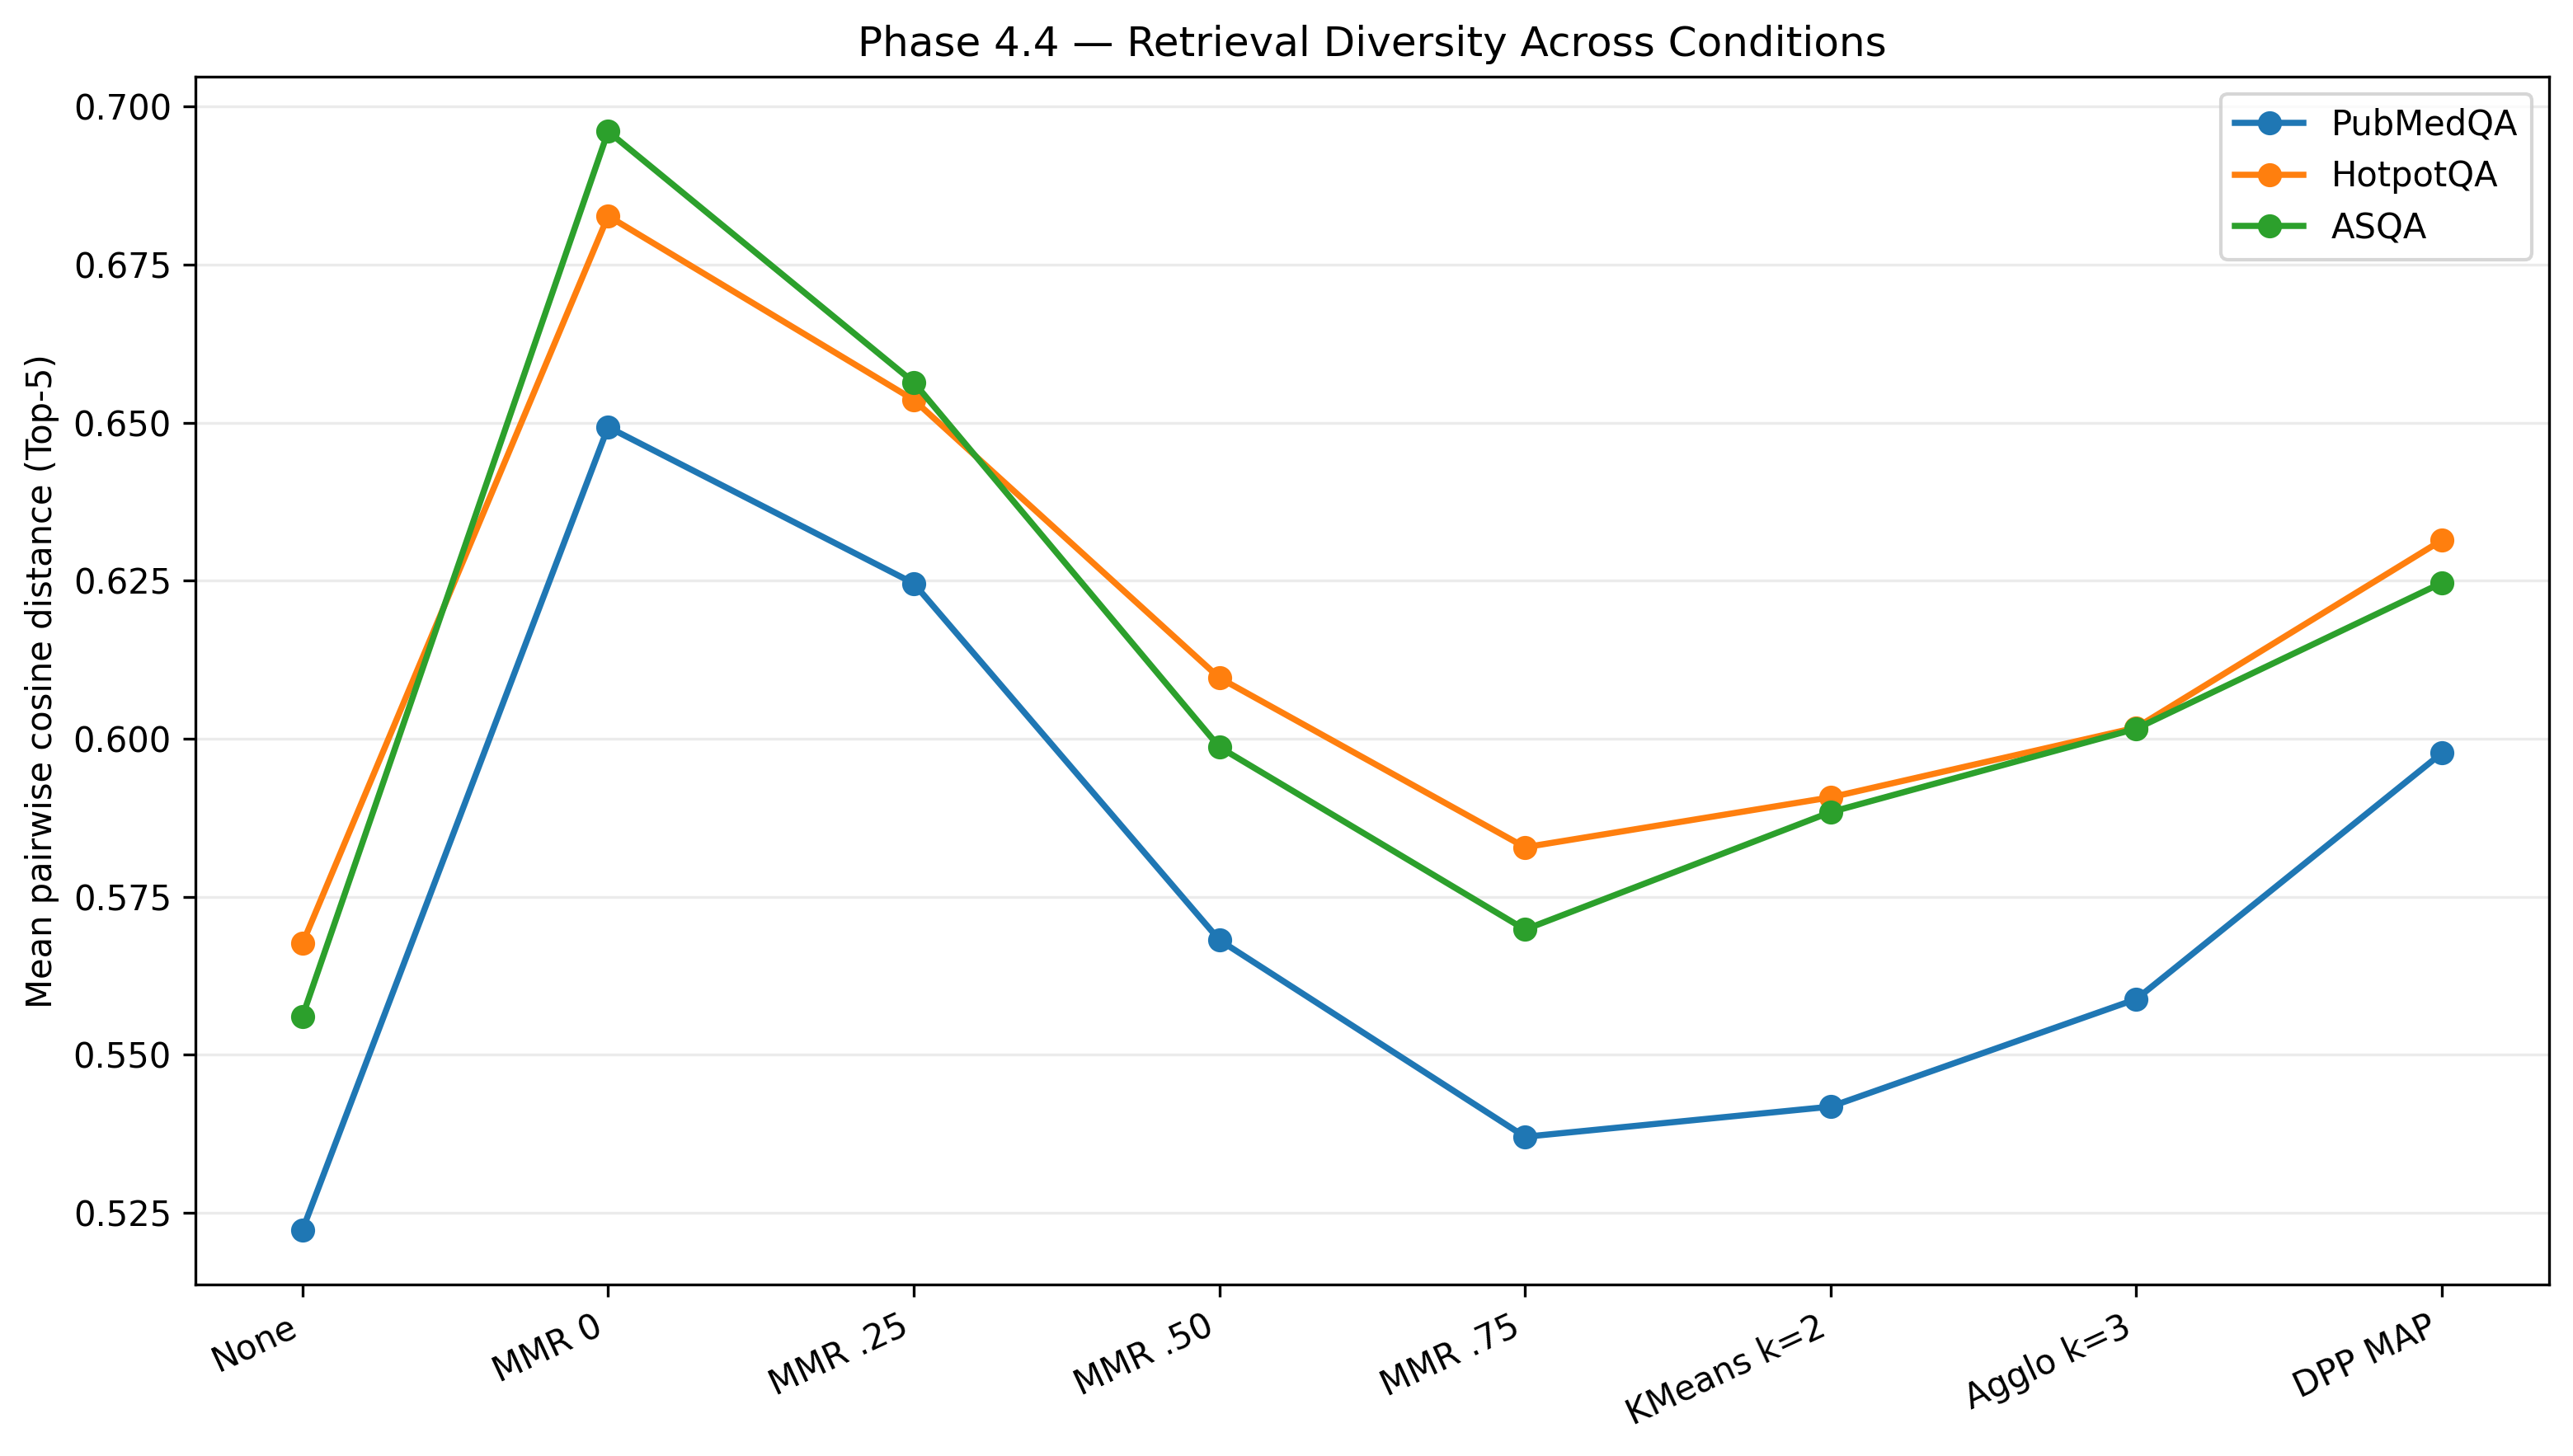

In [9]:
display(Image(filename=str(f14_path)))


## 8. Generation-package provenance

Sprint 2 generation is already complete.

The entries below are shown only to document the frozen generation packages used by the project; this notebook does not invoke generation.


In [10]:
generation_provenance = manifest[
    manifest["input_group"] == "GENERATION_PACKAGE_PROVENANCE"
][[
    "dataset",
    "evidence_role",
    "logical_id",
    "sha256",
]].copy()

display(
    generation_provenance
    .sort_values("dataset")
    .reset_index(drop=True)
)


,dataset,evidence_role,logical_id,sha256
0,asqa,PROJECT_PROTECTED_FINAL,package_manifest.json,a4f4215308b46006c56af8f4e085973dc7ce2e82775574...
1,hotpotqa,OFFICIAL_TEST_FULL,package_manifest.json,9bdb7350040ca46db08c20b2fcde7a9e8959b559d40df7...
2,pubmedqa,UNKNOWN,package_manifest.json,bc1f73a01fa12bf01403e01a69f87ffec30fa694a8999e...


## 9. Sprint 2 conclusion

Sprint 2 establishes three main findings:

1. **Diversification changes evidence composition.**
2. **Higher retrieval diversity can trade off against relevance or coverage.**
3. **The effect is configuration-dependent.**

Sprint 3 therefore evaluates whether these retrieval changes propagate to downstream correctness, faithfulness, hallucination behavior, coverage, output diversity, and robustness.


In [11]:
assert len(metrics) == 376
assert set(metrics["dataset"]) == {"pubmedqa", "hotpotqa", "asqa"}
assert set(metrics["condition"]) == set(condition_order)
assert (
    metrics[["dataset", "retriever"]]
    .drop_duplicates()
    .shape[0]
    == 11
)
assert len(manifest) == 18
assert f14_path.is_file()

print("SPRINT2_NOTEBOOK_DATA_VALIDATION=PASS")
print("SCIENTIFIC_RERUN=NO")
print("METRIC_RECOMPUTATION=NO")
print("PLOT_REGENERATION=NO")


SPRINT2_NOTEBOOK_DATA_VALIDATION=PASS
SCIENTIFIC_RERUN=NO
METRIC_RECOMPUTATION=NO
PLOT_REGENERATION=NO


## 10. Limitations

- Protected-final ASQA `S-Recall@5`, `alpha-nDCG@5`, coverability, and `c*` numeric artifacts are not available in the frozen final package and are not reconstructed here.
- ASQA retrieval diversity is a manipulation diagnostic, not an answer-quality metric.
- DEVELOPMENT and SELECTION artifacts are not substituted for protected-final evidence.
- No scientific artifact is modified by this notebook.
